In [1]:
from typing import TypedDict, List
from langgraph.graph import StateGraph, START, END
from langgraph.types import interrupt, Command
from langgraph.checkpoint.memory import MemorySaver
from langchain.chat_models import init_chat_model
from langchain_core.messages import HumanMessage, AIMessage
import os
from dotenv import load_dotenv


In [2]:
load_dotenv()

# -------------------
# 1. LLM
# -------------------
api_key = os.getenv("GOOGLE_API_KEY")

model = init_chat_model(
    "google_genai:gemini-2.5-flash-lite",
    api_key=api_key
)

d:\langgraphcourse\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# -----------------------------
# 1️⃣ Define State
# -----------------------------

class EmailState(TypedDict):
    messages: List
    draft_email: str
    approved: bool

In [4]:
# -----------------------------
# 3️⃣ Node 1 — Generate Email
# -----------------------------

def generate_email_node(state: EmailState):
    print("\n--- Generating Email Draft ---")

    response = model.invoke(state["messages"])

    return {
        "messages": state["messages"] + [response],
        "draft_email": response.content
    }


In [5]:
# -----------------------------
# 4️⃣ Node 2 — HITL Approval
# -----------------------------

def approval_node(state: EmailState):
    print("\n--- Pausing for Human Approval ---")

    # 👇 THIS IS THE PAUSE
    decision = interrupt({
        "question": "Do you approve sending this email?",
        "draft": state["draft_email"]
    })

    # 👇 This runs AFTER resume
    return {"approved": decision}


In [6]:
# -----------------------------
# 5️⃣ Node 3 — Send Email
# -----------------------------

def send_email_node(state: EmailState):
    if state["approved"]:
        print("\n✅ Email Sent Successfully!")
    else:
        print("\n❌ Email Cancelled!")

    return state

In [7]:
# -----------------------------
# 6️⃣ Build Graph
# -----------------------------

builder = StateGraph(EmailState)

builder.add_node("generate", generate_email_node)
builder.add_node("approval", approval_node)
builder.add_node("send", send_email_node)

builder.add_edge(START, "generate")
builder.add_edge("generate", "approval")
builder.add_edge("approval", "send")
builder.add_edge("send", END)

In [ ]:
# 👇 Checkpointer required for interrupt
graph = builder.compile(checkpointer=MemorySaver())

# 👇 thread_id = persistent cursor
config = {"configurable": {"thread_id": "email-thread-1"}}

In [9]:
# -----------------------------
# 7️⃣ First Run (Will Pause)
# -----------------------------

initial_input = {
    "messages": [HumanMessage(content="Write a professional email about project delay.")],
    "draft_email": "",
    "approved": False
}

result = graph.invoke(initial_input, config=config)

print("\n--- Graph Returned ---")
print(result)


--- Generating Email Draft ---

--- Pausing for Human Approval ---

--- Graph Returned ---
{'messages': [HumanMessage(content='Write a professional email about project delay.', additional_kwargs={}, response_metadata={}), AIMessage(content='Subject: Update on [Project Name] - Revised Timeline and Next Steps\n\nDear [Client/Stakeholder Name],\n\nI am writing to provide you with an important update regarding the timeline for the [Project Name] project.\n\nUnfortunately, we have encountered an unforeseen [briefly explain the reason for the delay, e.g., technical challenge, resource constraint, external dependency delay] that will impact our original delivery date. We have been diligently working to mitigate this issue and have explored several solutions to minimize the disruption.\n\nAfter careful assessment, we now anticipate a revised completion date of **[New Estimated Completion Date]**. This represents a delay of approximately **[Number] [days/weeks]** from our initial projection.\n

In [ ]:

#second run 
print("\n--- Resuming with Human Approval ---")

resumed = graph.invoke(
    Command(resume=True),  # 👈 human approves
    config=config
)

print("\n--- Final State ---")
print(resumed)


--- Resuming with Human Approval ---

--- Pausing for Human Approval ---

✅ Email Sent Successfully!

--- Final State ---
{'messages': [HumanMessage(content='Write a professional email about project delay.', additional_kwargs={}, response_metadata={}), AIMessage(content='Subject: Update on [Project Name] - Revised Timeline and Next Steps\n\nDear [Client/Stakeholder Name],\n\nI am writing to provide you with an important update regarding the timeline for the [Project Name] project.\n\nUnfortunately, we have encountered an unforeseen [briefly explain the reason for the delay, e.g., technical challenge, resource constraint, external dependency delay] that will impact our original delivery date. We have been diligently working to mitigate this issue and have explored several solutions to minimize the disruption.\n\nAfter careful assessment, we now anticipate a revised completion date of **[New Estimated Completion Date]**. This represents a delay of approximately **[Number] [days/weeks]**

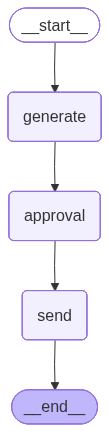

In [12]:
#graph image 
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

AttributeError: 'StateGraph' object has no attribute 'invoke'